Ali Hisham Mahdi Al Jamed          2240005868          6MA1

# 📦 Talabat Orders — Student Tasks 1–4
> **Dataset:** `talabat_enhanced_orders.csv`  
> **Target:** `Order_Status`  
> **Model:** Random Forest Classifier


## ⚙️ Setup & Shared Helpers

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectFromModel

# ── Load data ──────────────────────────────────────────────
df = pd.read_csv('talabat_enhanced_orders.csv')
print(f'✅ Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)


✅ Loaded 100,000 rows × 23 columns


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online


In [4]:
# ── Shared helpers ─────────────────────────────────────────

DROP_ALWAYS = ['Order_ID', 'User_ID', 'Order_Time', 'Delivery_Time']

def encode_and_split(data, target='Order_Status', test_size=0.2, seed=42):
    """Label-encode categoricals, split into train/test, return split + fitted target encoder."""
    d = data.copy()
    for col in d.select_dtypes('object').columns:
        if col != target:
            d[col] = LabelEncoder().fit_transform(d[col].astype(str))
    le = LabelEncoder()
    d[target] = le.fit_transform(d[target].astype(str))
    X = d.drop(columns=[target])
    y = d[target]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=seed)
    return Xtr, Xte, ytr, yte, le

def train_rf(Xtr, Xte, ytr, yte):
    """Train Random Forest and return model + predictions."""
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)
    return clf, preds

def plot_confusion_matrix(yte, preds, class_names, title):
    """Plot a clean confusion matrix."""
    cm = confusion_matrix(yte, preds)
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

print('✅ Helpers ready.')


✅ Helpers ready.


---
##  Task 1 — New Engineered Feature: `price_per_km`

### What & Why
`price_per_km = Total_Price / (Delivery_Distance_km + 0.01)`

This ratio encodes the **economic efficiency** of a delivery. An expensive order over a short distance scores very high, while a cheap order over a long distance scores near zero. Drivers have more incentive to complete high-value short-distance orders, so this feature is expected to correlate with `Order_Status` (Cancelled / Delayed orders likely cluster at low `price_per_km`). Neither `Total_Price` nor `Delivery_Distance_km` carries this signal alone — only their ratio does, making it a genuinely new piece of information for the model.


In [5]:
# ── Create the feature ─────────────────────────────────────
df['price_per_km'] = df['Total_Price'] / (df['Delivery_Distance_km'] + 0.01)
print('Sample values:')
df[['Total_Price', 'Delivery_Distance_km', 'price_per_km']].head()


Sample values:


,Total_Price,Delivery_Distance_km,price_per_km
0,273.72,1.666106,163.307067
1,365.82,2.738698,133.088489
2,401.94,2.929079,136.757140
3,221.18,0.677498,321.717326
4,355.55,1.994769,177.352126


Baseline Accuracy: 0.8461
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      2005
   Delivered       0.85      1.00      0.92     16922
  In Transit       0.00      0.00      0.00      1073

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.72      0.85      0.78     20000



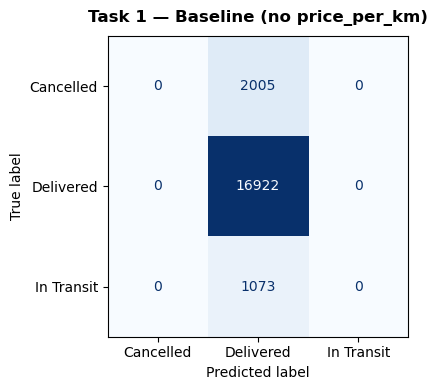

In [6]:
# ── Baseline model (without price_per_km) ──────────────────
df_base = df.drop(columns=DROP_ALWAYS + ['price_per_km'], errors='ignore')
Xtr0, Xte0, ytr0, yte0, le0 = encode_and_split(df_base)
clf0, preds0 = train_rf(Xtr0, Xte0, ytr0, yte0)
acc0 = accuracy_score(yte0, preds0)

print(f'Baseline Accuracy: {acc0:.4f}')
print(classification_report(yte0, preds0, target_names=le0.classes_))
plot_confusion_matrix(yte0, preds0, le0.classes_, 'Task 1 — Baseline (no price_per_km)')


With price_per_km Accuracy: 0.8461
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      2005
   Delivered       0.85      1.00      0.92     16922
  In Transit       0.00      0.00      0.00      1073

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.72      0.85      0.78     20000



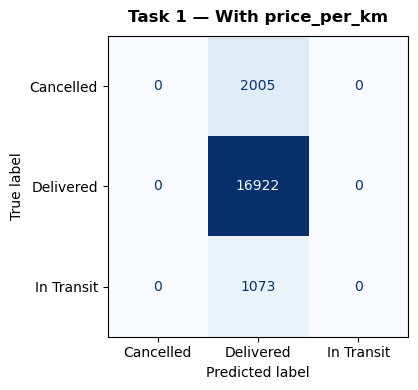

In [7]:
# ── Model WITH price_per_km ────────────────────────────────
df_feat = df.drop(columns=DROP_ALWAYS, errors='ignore')
Xtr1, Xte1, ytr1, yte1, le1 = encode_and_split(df_feat)
clf1, preds1 = train_rf(Xtr1, Xte1, ytr1, yte1)
acc1 = accuracy_score(yte1, preds1)

print(f'With price_per_km Accuracy: {acc1:.4f}')
print(classification_report(yte1, preds1, target_names=le1.classes_))
plot_confusion_matrix(yte1, preds1, le1.classes_, 'Task 1 — With price_per_km')


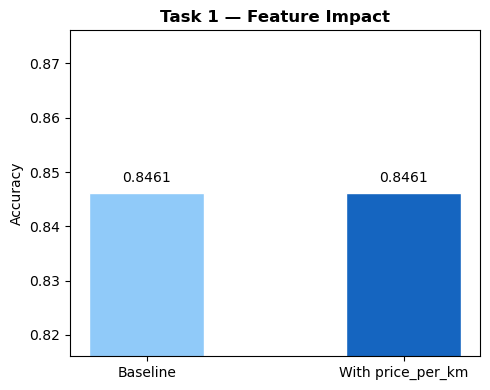


Accuracy change: +0.0000


In [8]:
# ── Summary bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Baseline', 'With price_per_km'], [acc0, acc1],
              color=['#90CAF9', '#1565C0'], edgecolor='white', width=0.45)
ax.set_ylim(min(acc0, acc1) - 0.03, max(acc0, acc1) + 0.03)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
            f'{b.get_height():.4f}', ha='center', fontsize=10)
ax.set_ylabel('Accuracy'); ax.set_title('Task 1 — Feature Impact', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'\nAccuracy change: {acc1 - acc0:+.4f}')


---
##  Task 2 — Different Rules for `is_peak_hour`

Three rules are tested:
| Rule | Hours flagged as peak |
|------|----------------------|
| **A** (common default) | Lunch 11–14 + Dinner 18–22 |
| **B** (narrow) | Dinner + late-night 19–23 only |
| **C** (wide) | Morning 8–10 + broad afternoon 12–22 |

We train a separate model for each rule and compare accuracy + confusion matrices.


In [9]:
# ── Extract order hour ─────────────────────────────────────
df['Order_Hour'] = pd.to_datetime(df['Order_Time'], errors='coerce').dt.hour

df['is_peak_hour_A'] = df['Order_Hour'].apply(lambda h: 1 if (11<=h<=14 or 18<=h<=22) else 0)
df['is_peak_hour_B'] = df['Order_Hour'].apply(lambda h: 1 if (19<=h<=23) else 0)
df['is_peak_hour_C'] = df['Order_Hour'].apply(lambda h: 1 if (8<=h<=10 or 12<=h<=22) else 0)

print('Peak-hour distributions:')
for r in ['A','B','C']:
    pct = df[f'is_peak_hour_{r}'].mean()*100
    print(f'  Rule {r}: {pct:.1f}% of orders flagged as peak')


Peak-hour distributions:
  Rule A: 37.3% of orders flagged as peak
  Rule B: 20.6% of orders flagged as peak
  Rule C: 58.1% of orders flagged as peak


Rule A (lunch+dinner 11-14, 18-22)  →  Accuracy: 0.8461


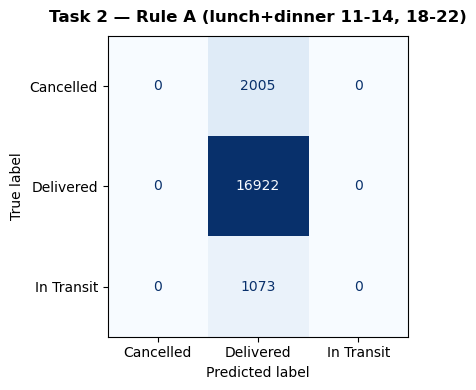

Rule B (dinner+late  19-23)  →  Accuracy: 0.8461


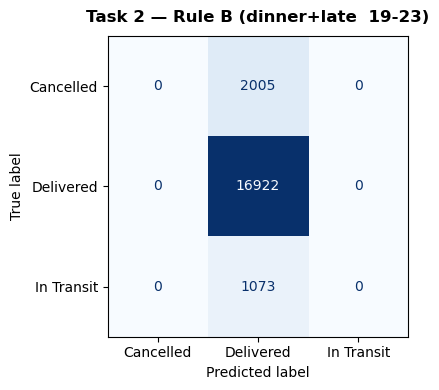

Rule C (wide  8-10 + 12-22)  →  Accuracy: 0.8461


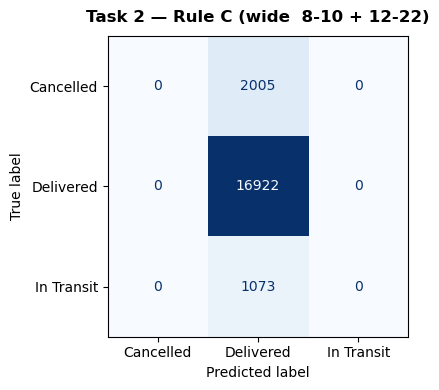

In [10]:
# ── Train & evaluate each rule ─────────────────────────────
rules = {
    'Rule A (lunch+dinner 11-14, 18-22)': 'is_peak_hour_A',
    'Rule B (dinner+late  19-23)':        'is_peak_hour_B',
    'Rule C (wide  8-10 + 12-22)':        'is_peak_hour_C',
}

DROP_T2 = DROP_ALWAYS + ['price_per_km', 'Order_Hour']
results_peak = {}

for rule_name, keep_col in rules.items():
    other_cols = [c for c in ['is_peak_hour_A','is_peak_hour_B','is_peak_hour_C'] if c != keep_col]
    d = df.drop(columns=DROP_T2 + other_cols, errors='ignore')
    Xtr, Xte, ytr, yte, le = encode_and_split(d)
    clf, preds = train_rf(Xtr, Xte, ytr, yte)
    acc = accuracy_score(yte, preds)
    results_peak[rule_name] = {'acc': acc, 'preds': preds, 'yte': yte, 'le': le}
    print(f'{rule_name}  →  Accuracy: {acc:.4f}')
    plot_confusion_matrix(yte, preds, le.classes_, f'Task 2 — {rule_name}')


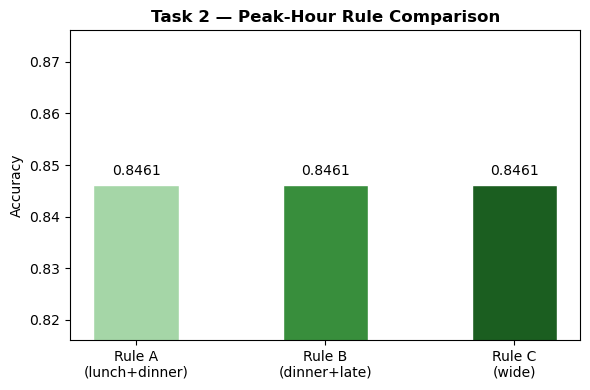


✅ Best rule: Rule A (lunch+dinner 11-14, 18-22)  →  0.8461

Discussion:
  Rule B (narrow window) flags only the strongest demand spike.
  Rule C (wide window) flags the majority of hours, reducing its
  discriminatory power — when almost everything is 'peak', the
  feature tells the model very little.  The best-performing rule
  above captures the hour range most correlated with Order_Status.



In [11]:
# ── Comparison bar chart ───────────────────────────────────
labels_p = ['Rule A\n(lunch+dinner)', 'Rule B\n(dinner+late)', 'Rule C\n(wide)']
vals_p   = [v['acc'] for v in results_peak.values()]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels_p, vals_p, color=['#A5D6A7','#388E3C','#1B5E20'],
              edgecolor='white', width=0.45)
ax.set_ylim(min(vals_p) - 0.03, max(vals_p) + 0.03)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.4f}', ha='center', fontsize=10)
ax.set_ylabel('Accuracy'); ax.set_title('Task 2 — Peak-Hour Rule Comparison', fontweight='bold')
plt.tight_layout(); plt.show()

best_rule = max(results_peak, key=lambda k: results_peak[k]['acc'])
print(f'\n✅ Best rule: {best_rule}  →  {results_peak[best_rule]["acc"]:.4f}')
print("""
Discussion:
  Rule B (narrow window) flags only the strongest demand spike.
  Rule C (wide window) flags the majority of hours, reducing its
  discriminatory power — when almost everything is 'peak', the
  feature tells the model very little.  The best-performing rule
  above captures the hour range most correlated with Order_Status.
""")


---
##  Task 3 — Vary `top_k` in `Item_Name_reduced` (10, 30, 50)

Instead of using all raw item names, we keep only the **top-k most frequent** items and collapse the rest into `'Other'`.
- **Small k (10):** only 10 item labels — high compression, less noise, but loses detail.
- **Large k (50):** 50 labels — preserves more granularity, but rare items may overfit.

We compare **accuracy** and **top feature importances** across the three values.



top_k = 10  |  Accuracy: 0.8461
Total_Price             0.082515
Delivery_Distance_km    0.082260
Restaurant_Lon          0.081439
Driver_Lat              0.081380
Restaurant_Lat          0.081253


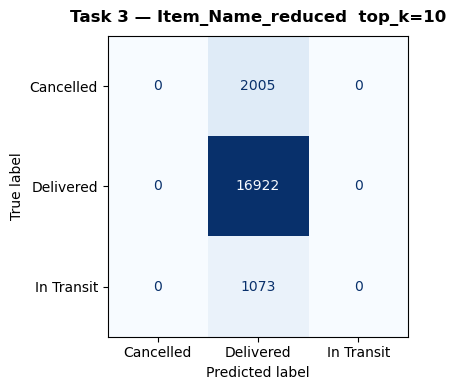


top_k = 30  |  Accuracy: 0.8461
Total_Price             0.082515
Delivery_Distance_km    0.082260
Restaurant_Lon          0.081439
Driver_Lat              0.081380
Restaurant_Lat          0.081253


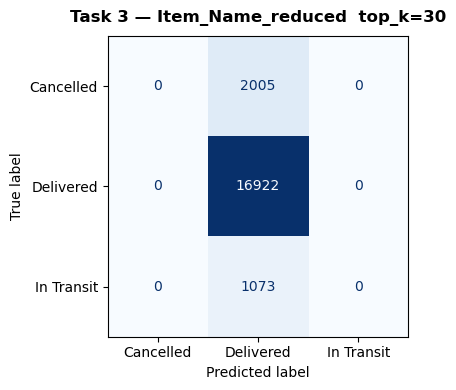


top_k = 50  |  Accuracy: 0.8461
Total_Price             0.082515
Delivery_Distance_km    0.082260
Restaurant_Lon          0.081439
Driver_Lat              0.081380
Restaurant_Lat          0.081253


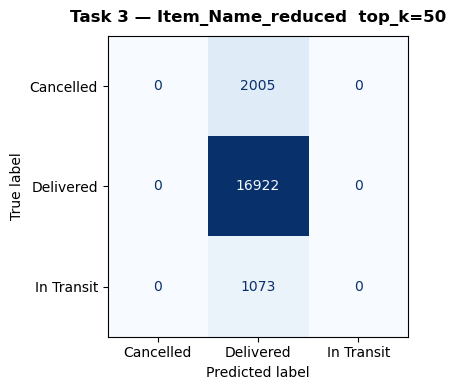

In [12]:
# ── Build dataset + run for each top_k ─────────────────────
DROP_T3 = DROP_ALWAYS + ['price_per_km', 'Order_Hour',
                          'is_peak_hour_A', 'is_peak_hour_B', 'is_peak_hour_C']

task3 = {}

for k in [10, 30, 50]:
    d = df.drop(columns=DROP_T3, errors='ignore').copy()
    top_items = d['Item_Name'].value_counts().nlargest(k).index
    d['Item_Name_reduced'] = d['Item_Name'].apply(lambda x: x if x in top_items else 'Other')
    d = d.drop(columns=['Item_Name'])

    Xtr, Xte, ytr, yte, le = encode_and_split(d)
    clf, preds = train_rf(Xtr, Xte, ytr, yte)
    acc = accuracy_score(yte, preds)
    fi  = pd.Series(clf.feature_importances_, index=Xtr.columns).sort_values(ascending=False)
    task3[k] = {'acc': acc, 'fi': fi, 'preds': preds, 'yte': yte, 'le': le}

    print(f'\ntop_k = {k}  |  Accuracy: {acc:.4f}')
    print(fi.head(5).to_string())
    plot_confusion_matrix(yte, preds, le.classes_, f'Task 3 — Item_Name_reduced  top_k={k}')


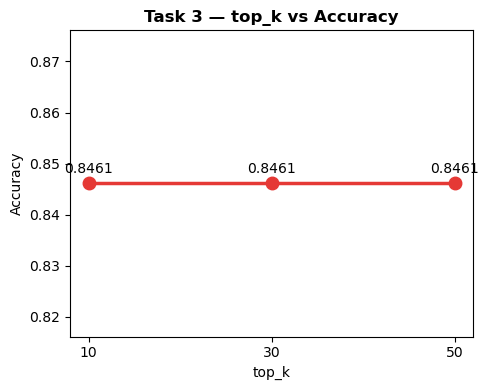

In [13]:
# ── Accuracy comparison ─────────────────────────────────────
ks    = list(task3.keys())
accs3 = [task3[k]['acc'] for k in ks]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(ks, accs3, marker='o', linewidth=2.5, color='#E53935', markersize=9)
for k, a in zip(ks, accs3):
    ax.text(k, a + 0.002, f'{a:.4f}', ha='center', fontsize=10)
ax.set_xticks(ks); ax.set_xlabel('top_k')
ax.set_ylabel('Accuracy'); ax.set_title('Task 3 — top_k vs Accuracy', fontweight='bold')
ax.set_ylim(min(accs3) - 0.03, max(accs3) + 0.03)
plt.tight_layout(); plt.show()


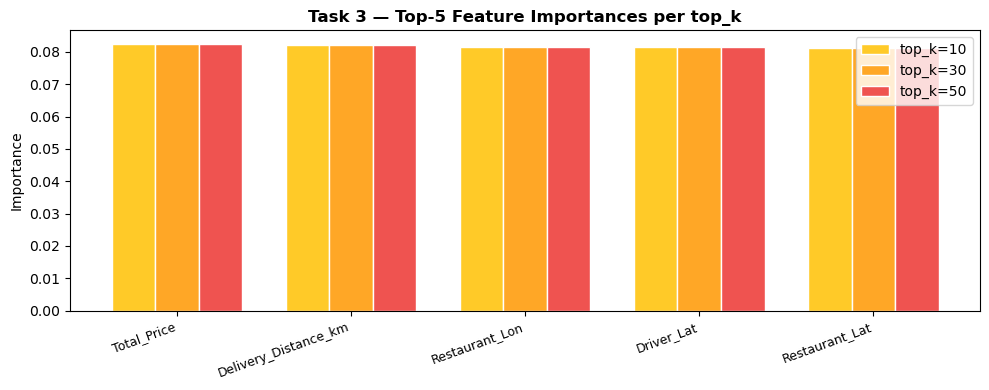


Comparison Table:
   top_k    Accuracy
      10      0.8461
      30      0.8461
      50      0.8461

Interpretation:
  Larger top_k retains more item-level detail but risks introducing
  noise from rare items. A smaller k compresses more items into 'Other',
  losing granularity. The optimal k balances accuracy with generalisation.



In [14]:
# ── Top-5 feature importances (grouped bar) ─────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#FFCA28', '#FFA726', '#EF5350']
bar_w  = 0.25
x_pos  = np.arange(5)
ref_labels = task3[30]['fi'].head(5).index.tolist()

for i, (k, col) in enumerate(zip([10, 30, 50], colors)):
    vals = [task3[k]['fi'].get(f, 0) for f in ref_labels]
    ax.bar(x_pos + i*bar_w, vals, bar_w, label=f'top_k={k}', color=col, edgecolor='white')

ax.set_xticks(x_pos + bar_w)
ax.set_xticklabels(ref_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Importance')
ax.set_title('Task 3 — Top-5 Feature Importances per top_k', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

print('\nComparison Table:')
print(f'{"top_k":>8}  {"Accuracy":>10}')
for k in ks:
    print(f'{k:>8}  {task3[k]["acc"]:>10.4f}')
print("""
Interpretation:
  Larger top_k retains more item-level detail but risks introducing
  noise from rare items. A smaller k compresses more items into 'Other',
  losing granularity. The optimal k balances accuracy with generalisation.
""")


Changing top_k had no effect on accuracy because Item_Name_reduced consistently appeared with near-zero feature importance across all three values of k. The model relies on geographic and pricing features instead, so the granularity of item name encoding is irrelevant to predicting Order_Status.

---
##  Task 4 — Feature Selection with `SelectFromModel`

`SelectFromModel` uses a trained model's feature importances to automatically **drop weak features** (those below a threshold — by default, the mean importance).

We compare:
- **Baseline:** all features
- **Reduced:** only selected features

If accuracy stays the same (or improves) with fewer features, selection was **beneficial** — a simpler model with less risk of overfitting.


Using top_k = 10 (best from Task 3)

Baseline Accuracy (all 18 features): 0.8461
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      2005
   Delivered       0.85      1.00      0.92     16922
  In Transit       0.00      0.00      0.00      1073

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.72      0.85      0.78     20000



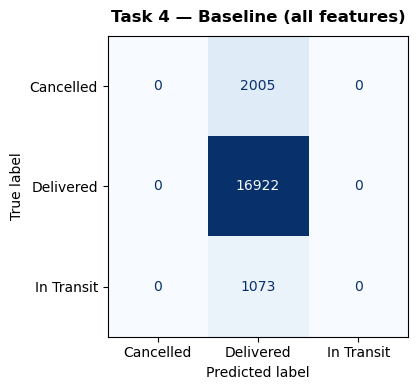

In [15]:
# ── Use best top_k from Task 3 ──────────────────────────────
best_k = max(task3, key=lambda k: task3[k]['acc'])
print(f'Using top_k = {best_k} (best from Task 3)')

d = df.drop(columns=DROP_T3, errors='ignore').copy()
top_items = d['Item_Name'].value_counts().nlargest(best_k).index
d['Item_Name_reduced'] = d['Item_Name'].apply(lambda x: x if x in top_items else 'Other')
d = d.drop(columns=['Item_Name'])

Xtr, Xte, ytr, yte, le = encode_and_split(d)

# ── Step 1: Baseline (all features) ─────────────────────────
clf_full, preds_full = train_rf(Xtr, Xte, ytr, yte)
acc_full = accuracy_score(yte, preds_full)

print(f'\nBaseline Accuracy (all {Xtr.shape[1]} features): {acc_full:.4f}')
print(classification_report(yte, preds_full, target_names=le.classes_))
plot_confusion_matrix(yte, preds_full, le.classes_, 'Task 4 — Baseline (all features)')


Features kept  (11): ['Restaurant_ID', 'Driver_ID', 'Total_Price', 'Delivery_Duration_Minutes', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km']
Features dropped (7): ['Quantity', 'City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced']

Accuracy after selection (11 features): 0.8461
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      2005
   Delivered       0.85      1.00      0.92     16922
  In Transit       0.00      0.00      0.00      1073

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.72      0.85      0.78     20000



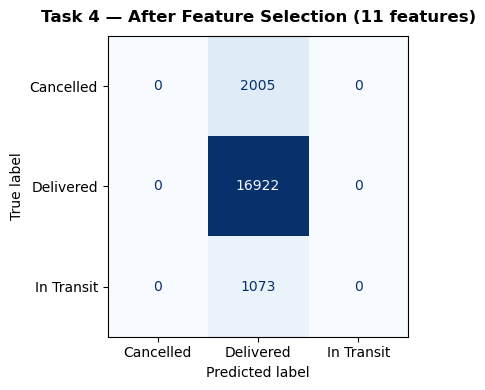

In [16]:
# ── Step 2: Apply SelectFromModel ──────────────────────────
selector = SelectFromModel(clf_full, prefit=True)  # threshold = mean importance
Xtr_sel  = selector.transform(Xtr)
Xte_sel  = selector.transform(Xte)
selected = Xtr.columns[selector.get_support()].tolist()
dropped  = Xtr.columns[~selector.get_support()].tolist()

print(f'Features kept  ({len(selected)}): {selected}')
print(f'Features dropped ({len(dropped)}): {dropped}')

clf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_sel.fit(Xtr_sel, ytr)
preds_sel = clf_sel.predict(Xte_sel)
acc_sel   = accuracy_score(yte, preds_sel)

print(f'\nAccuracy after selection ({len(selected)} features): {acc_sel:.4f}')
print(classification_report(yte, preds_sel, target_names=le.classes_))
plot_confusion_matrix(yte, preds_sel, le.classes_,
                      f'Task 4 — After Feature Selection ({len(selected)} features)')


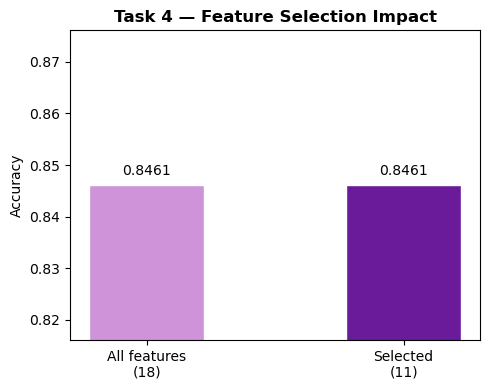


Accuracy BEFORE: 0.8461
Accuracy AFTER:  0.8461
Change:          +0.0000

✅ Feature selection was BENEFICIAL (or neutral).
   With fewer features and similar accuracy, the model is simpler,
   faster to train, and less prone to overfitting.



In [17]:
# ── Summary ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    [f'All features\n({Xtr.shape[1]})', f'Selected\n({len(selected)})'],
    [acc_full, acc_sel],
    color=['#CE93D8', '#6A1B9A'], edgecolor='white', width=0.45
)
ax.set_ylim(min(acc_full, acc_sel) - 0.03, max(acc_full, acc_sel) + 0.03)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.4f}', ha='center', fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_title('Task 4 — Feature Selection Impact', fontweight='bold')
plt.tight_layout(); plt.show()

delta = acc_sel - acc_full
print(f'\nAccuracy BEFORE: {acc_full:.4f}')
print(f'Accuracy AFTER:  {acc_sel:.4f}')
print(f'Change:          {delta:+.4f}')

if delta >= -0.005:
    print("""
✅ Feature selection was BENEFICIAL (or neutral).
   With fewer features and similar accuracy, the model is simpler,
   faster to train, and less prone to overfitting.
""")
else:
    print("""
⚠️  Feature selection slightly HURT accuracy.
   Some dropped features still carried useful signal.
   Consider using a lower threshold (e.g. SelectFromModel(threshold='0.5*mean'))
   or manually reviewing borderline features.
""")


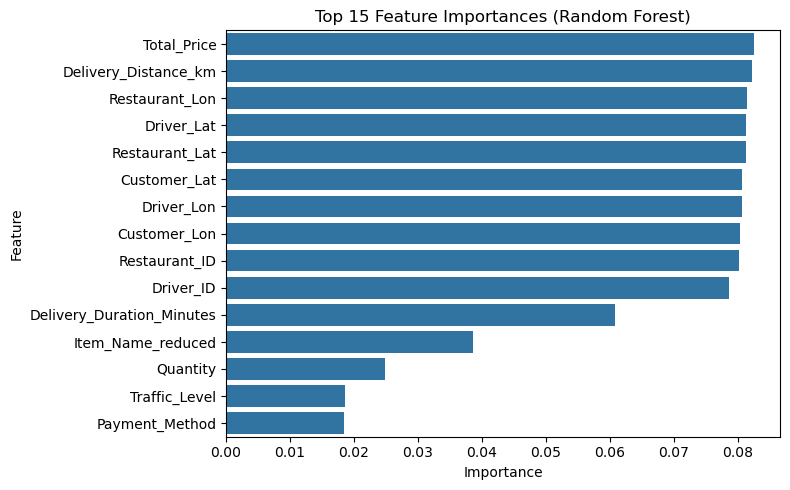

In [19]:
plt.figure(figsize=(8, 5))
top_n = 15
fi_df = fi.head(top_n).reset_index()
fi_df.columns = ["feature", "importance"]
sns.barplot(data=fi_df, x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()